# Exploratory Data Analysis - Bangla Sentiment Dataset

This notebook performs basic EDA on `data/raw/large_sentiment_analysis_dataset.csv`:
- load dataset
- inspect schema and sample rows
- count labels and plot class distribution
- check text length distribution, duplicates and missing values
- sample examples per class

Run each cell in order. If you run this locally, make sure `pandas`, `matplotlib`, and `seaborn` are installed (they are in `requirements.txt`).

In [2]:
# Cell 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")

In [3]:
# Cell 2: Load data
csv_path = "../data/raw/large_sentiment_analysis_dataset.csv"
df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", df.shape)
df.head(8)

Loaded: ../data/raw/large_sentiment_analysis_dataset.csv
Shape: (100000, 4)


,Platform,Comment,Sentiment,Label
0,YouTube,হাসতে হাসতে পেট ফেটে যাবে,Funny,3
1,Twitter,আজকে আমি খুবই দুঃখিত,Sad,2
2,Twitter,আমার সময় নষ্ট হলো,Toxic,0
3,Google,খুবই আনন্দিত,Happy,4
4,Twitter,আমি খুব খুশি,Happy,4
5,YouTube,খুবই মজার ছিল,Funny,3
6,Twitter,খুবই মজার ছিল,Funny,3
7,Google,আজকের দিনটা ভালো লাগছে,Happy,4


In [5]:
# Cell 3: Column names and types
df.dtypes

# Quick value counts for the target column
print("Label counts (Sentiment):")
print(df['Sentiment'].value_counts(dropna=False))

Label counts (Sentiment):
Sentiment
Funny      20130
Happy      20007
Sad        19972
Toxic      19966
Neutral    19925
Name: count, dtype: int64


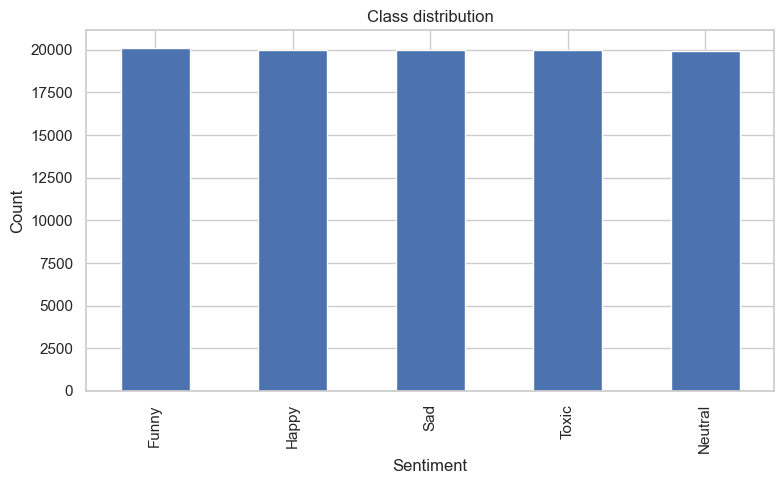

In [6]:
# Cell 4: Class distribution bar plot
plt.figure(figsize=(8,5))
ax = df['Sentiment'].value_counts().sort_values(ascending=False).plot(kind='bar', color='C0')
ax.set_title('Class distribution')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

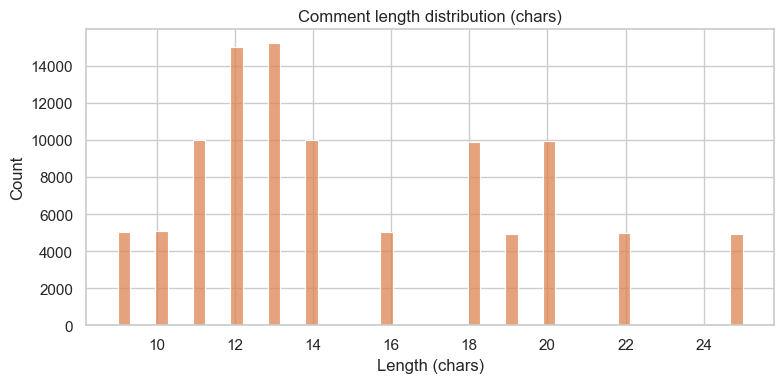

In [7]:
# Cell 5: Text length distribution
df['text_length'] = df['Comment'].astype(str).str.len()
plt.figure(figsize=(8,4))
sns.histplot(df['text_length'], bins=50, kde=False, color='C1')
plt.title('Comment length distribution (chars)')
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [9]:
# Cell 6: Missing values and duplicates
print('Missing per column:', df.isna().sum())
dupes = df.duplicated().sum()
print('Total duplicate rows:', dupes)
# If there are duplicate text rows you may want to inspect them
if dupes > 0:
    display(df[df.duplicated()][:5])

Missing per column: Platform       0
Comment        0
Sentiment      0
Label          0
text_length    0
dtype: int64
Total duplicate rows: 99940


,Platform,Comment,Sentiment,Label,text_length
11,Twitter,আজকে আমি খুবই দুঃখিত,Sad,2,20
20,YouTube,হাসতে হাসতে পেট ফেটে যাবে,Funny,3,25
22,YouTube,আমার সময় নষ্ট হলো,Toxic,0,18
24,Twitter,খুবই মজার ছিল,Funny,3,13
28,Google,আমার মন খারাপ,Sad,2,13


In [10]:
# Cell 7: Sample examples per class
for label in df['Sentiment'].unique():
    print('---', label, '---')
    display(df[df['Sentiment']==label]['Comment'].sample(n=3, random_state=42).tolist())

--- Funny ---


['হাসতে হাসতে পেট ফেটে যাবে', 'তুমি খুব মজার', 'এটা খুব মজার ভিডিও']

--- Sad ---


['আমি দুঃখিত', 'আমি দুঃখিত', 'আজকে আমি খুবই দুঃখিত']

--- Toxic ---


['ভয়ঙ্কর অভিজ্ঞতা', 'আমার সময় নষ্ট হলো', 'এটা খুবই বাজে ভিডিও']

--- Happy ---


['খুবই আনন্দিত', 'দারুণ লাগছে', 'খুবই আনন্দিত']

--- Neutral ---


['এটা ঠিক আছে', 'এটা ঠিক আছে', 'এটা ঠিক আছে']

In [11]:
# Cell 8: Create stratified train/test split and save (for next steps)
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, stratify=df['Sentiment'], random_state=42)
train.to_csv('../data/processed/train.csv', index=False)
test.to_csv('../data/processed/test.csv', index=False)
print('Saved train/test to data/processed (train:', len(train), 'test:', len(test),')')

Saved train/test to data/processed (train: 80000 test: 20000 )


## Next steps
- Implement and test `src/data_preprocessing.py` on `data/processed/train.csv`.
- Train baseline models using `src/model_training.py`.
- Evaluate with macro F1 and per-class metrics.